# Step 2.3.1 — YOLO Global 3D Projection (NEW — this was missing) ✅

| | |
|---|---|
| **Input** | `output/step_2/yolo/<sample>/<camera>.json` (2D boxes, from Step 2.3) |
| | `output/step_1/lidar/<sample>/lidar_raw.npy` + `lidar_meta.json` (from Step 1.3) |
| | `output/step_1/camera_meta.json` (from Step 1.1) |
| **Outputs** | `output/step_2/yolo_global/<sample>/<camera>.json` — each detection now has an estimated 3D global position |
| | `output/step_2/yolo_global_summary.csv` — match rate per sample/camera |
| **Used by** | Step 4.3 (camera multi-frame tracker — needs 3D global position for nearest-neighbor matching) |

---

### Why this notebook exists

Your "Validate Step 2.3.1" notebook checks that a folder of projection results exists — but the notebook that actually **computes** those projections wasn't among your files. Since Step 4.3 is literally named "Camera Multi-Frame Tracker (Global 3D Nearest-Neighbor Logic)," it needs a 3D global position per 2D detection to do that matching — and that has to come from somewhere. This notebook is that missing source.

### How it works

A single camera image alone cannot tell you an object's distance — that's the classic monocular depth ambiguity. The standard fix (and what real ADAS perception stacks do) is to borrow depth from LiDAR:

1. Project every LiDAR point from this sample onto the camera's image plane (reusing `project_point_to_camera` logic from Step 1.1).
2. For each YOLO 2D bounding box, find which projected LiDAR points fall inside it.
3. Take the **median** depth of those points (median, not mean — robust to a few background points sneaking into the box edges).
4. The matched LiDAR point's actual 3D global-frame position becomes the detection's estimated 3D position.
5. If no LiDAR points fall inside a box (sparse LiDAR at long range, or object outside LiDAR's field of view), the detection is flagged `has_3d_position: false` rather than guessing.

In [1]:
# ─────────────────────────────────────────────────────────────────
# CELL 1 — Verify config.py exists
# ─────────────────────────────────────────────────────────────────

from pathlib import Path

if not Path("config.py").exists():
    raise FileNotFoundError("config.py not found. Copy it from the repo root.")

from config import DATA_ROOT, STEP0_DIR, STEP1_DIR, STEP2_DIR

YOLO_IN_DIR    = STEP2_DIR / "yolo"
LIDAR_IN_DIR   = STEP1_DIR / "lidar"
YOLO_OUT_DIR   = STEP2_DIR / "yolo_global"
YOLO_OUT_DIR.mkdir(parents=True, exist_ok=True)

cam_meta_path = STEP1_DIR / "camera_meta.json"

for p, name in [(YOLO_IN_DIR, "Step 2.3 YOLO output"), (LIDAR_IN_DIR, "Step 1.3 LiDAR output"),
                 (cam_meta_path, "Step 1.1 camera_meta.json")]:
    if not p.exists():
        raise FileNotFoundError(f"{name} not found at {p} — run that step first.")

print(f"✅ YOLO_IN_DIR : {YOLO_IN_DIR}")
print(f"✅ LIDAR_IN_DIR: {LIDAR_IN_DIR}")
print(f"✅ YOLO_OUT_DIR: {YOLO_OUT_DIR}")

config.py loaded. PROJECT_ROOT = F:\Sensor fusion Research
DATA_ROOT   = F:\Sensor fusion Research\DATA SET\archive
OUTPUT_ROOT = F:\Sensor fusion Research\output
✅ YOLO_IN_DIR : F:\Sensor fusion Research\output\step_2\yolo
✅ LIDAR_IN_DIR: F:\Sensor fusion Research\output\step_1\lidar
✅ YOLO_OUT_DIR: F:\Sensor fusion Research\output\step_2\yolo_global


In [2]:
# ─────────────────────────────────────────────────────────────────
# CELL 2 — Vectorized projection utilities
# Moved to src/geometry.py — shared with Step 1.1, Step 3.1, Step 3.2
# ─────────────────────────────────────────────────────────────────

import numpy as np
from pyquaternion import Quaternion
from src.geometry import transform_matrix, points_to_global, global_points_to_camera

print("\u2705 Vectorized projection utilities loaded.")


✅ Vectorized projection utilities loaded.


In [3]:
# ─────────────────────────────────────────────────────────────────
# CELL 3 — Main pipeline: match YOLO 2D boxes to LiDAR-derived 3D positions
# ─────────────────────────────────────────────────────────────────

import json
from tqdm import tqdm

with open(cam_meta_path) as f:
    cam_meta_data = json.load(f)

with open(STEP0_DIR / "samples_index.json") as f:
    samples_index = json.load(f)

summary_rows = []

for sample_id in tqdm(sorted(samples_index.keys()), desc="Projecting YOLO to 3D"):
    yolo_sample_dir = YOLO_IN_DIR / sample_id
    lidar_sample_dir = LIDAR_IN_DIR / sample_id

    if not yolo_sample_dir.exists() or not lidar_sample_dir.exists():
        continue

    # Load LiDAR points + calibration for this sample
    lidar_pts = np.load(lidar_sample_dir / "lidar_raw.npy")[:, :3]   # x,y,z only
    with open(lidar_sample_dir / "lidar_meta.json") as f:
        lidar_meta = json.load(f)

    lidar_ego_pose = lidar_meta["ego_pose"]
    lidar_calib = {
        "translation": lidar_meta["sensor_to_ego_translation"],
        "rotation": lidar_meta["sensor_to_ego_rotation"]
    }

    # LiDAR points -> global frame, once per sample (reused across all 6 cameras)
    lidar_pts_global = points_to_global(lidar_pts, lidar_ego_pose, lidar_calib)

    if sample_id not in cam_meta_data:
        continue

    out_sample_dir = YOLO_OUT_DIR / sample_id
    out_sample_dir.mkdir(parents=True, exist_ok=True)

    for cam_name, cam_entry in cam_meta_data[sample_id].items():
        yolo_file = yolo_sample_dir / f"{cam_name}.json"
        if not yolo_file.exists():
            continue

        with open(yolo_file) as f:
            detections = json.load(f)

        if len(detections) == 0:
            with open(out_sample_dir / f"{cam_name}.json", "w") as f:
                json.dump([], f, indent=2)
            continue

        cam_ego_pose = cam_entry["ego_pose"]
        cam_calib = cam_entry["calibrated_sensor"]
        camera_intrinsic = cam_calib["camera_intrinsic"]

        # Project ALL LiDAR points onto THIS camera, once
        u, v, depth, valid = global_points_to_camera(
            lidar_pts_global, cam_ego_pose, cam_calib, camera_intrinsic
        )
        u_valid, v_valid = u[valid], v[valid]
        global_valid = lidar_pts_global[valid]
        depth_valid = depth[valid]

        n_matched = 0
        enriched_detections = []

        for det in detections:
            in_box = (
                (u_valid >= det["xmin"]) & (u_valid <= det["xmax"]) &
                (v_valid >= det["ymin"]) & (v_valid <= det["ymax"])
            )
            n_points_in_box = int(in_box.sum())

            enriched = dict(det)
            enriched["num_lidar_points_matched"] = n_points_in_box

            if n_points_in_box > 0:
                # Median depth is robust to a few stray background points at the box edges
                box_depths = depth_valid[in_box]
                median_depth = np.median(box_depths)
                closest_idx = np.argmin(np.abs(box_depths - median_depth))
                matched_global_xyz = global_valid[in_box][closest_idx]

                enriched["has_3d_position"] = True
                enriched["global_x"] = float(matched_global_xyz[0])
                enriched["global_y"] = float(matched_global_xyz[1])
                enriched["global_z"] = float(matched_global_xyz[2])
                enriched["estimated_depth_m"] = float(median_depth)
                n_matched += 1
            else:
                enriched["has_3d_position"] = False

            enriched_detections.append(enriched)

        with open(out_sample_dir / f"{cam_name}.json", "w") as f:
            json.dump(enriched_detections, f, indent=2)

        summary_rows.append({
            "sample_id": sample_id,
            "camera": cam_name,
            "num_detections": len(detections),
            "num_matched_3d": n_matched,
            "match_rate": round(n_matched / len(detections) * 100, 1) if detections else 0.0
        })

assert len(summary_rows) > 0, "No samples processed — check input paths"
print(f"\n✅ Step 2.3.1 complete: {len(summary_rows)} sample/camera combinations processed.")

Projecting YOLO to 3D:   0%|          | 0/404 [00:00<?, ?it/s]

Projecting YOLO to 3D:   0%|          | 1/404 [00:00<01:39,  4.07it/s]

Projecting YOLO to 3D:   1%|          | 3/404 [00:00<00:40,  9.87it/s]

Projecting YOLO to 3D:   1%|          | 5/404 [00:00<00:30, 13.05it/s]

Projecting YOLO to 3D:   2%|▏         | 7/404 [00:00<00:29, 13.64it/s]

...

Projecting YOLO to 3D:  99%|█████████▉| 399/404 [00:29<00:00, 11.52it/s]

Projecting YOLO to 3D:  99%|█████████▉| 401/404 [00:29<00:00, 12.61it/s]

Projecting YOLO to 3D: 100%|█████████▉| 403/404 [00:29<00:00, 13.83it/s]

Projecting YOLO to 3D: 100%|██████████| 404/404 [00:29<00:00, 13.73it/s]


✅ Step 2.3.1 complete: 1747 sample/camera combinations processed.


In [4]:
# ─────────────────────────────────────────────────────────────────
# CELL 4 — Summary: how well did LiDAR-camera matching work?
# ─────────────────────────────────────────────────────────────────

import pandas as pd

summary_df = pd.DataFrame(summary_rows)
summary_path = STEP2_DIR / "yolo_global_summary.csv"
summary_df.to_csv(summary_path, index=False)

overall_match_rate = summary_df["num_matched_3d"].sum() / summary_df["num_detections"].sum() * 100

print(f"✅ Summary saved: {summary_path}")
print(f"   Overall 3D match rate: {overall_match_rate:.1f}%")
print(f"   (detections with zero matched LiDAR points keep has_3d_position=false —")
print(f"    typically distant objects or ones outside LiDAR's field of view)")

by_camera = summary_df.groupby("camera")["match_rate"].mean().sort_values(ascending=False)
print("\nMatch rate by camera:")
display(by_camera)

✅ Summary saved: F:\Sensor fusion Research\output\step_2\yolo_global_summary.csv
   Overall 3D match rate: 97.1%
   (detections with zero matched LiDAR points keep has_3d_position=false —
    typically distant objects or ones outside LiDAR's field of view)

Match rate by camera:


camera
CAM_BACK_LEFT      99.924339
CAM_BACK_RIGHT     99.416456
CAM_BACK           99.345730
CAM_FRONT_LEFT     98.944583
CAM_FRONT_RIGHT    98.410264
CAM_FRONT          91.990981
Name: match_rate, dtype: float64

## Visual check: does the 3D estimate make sense?

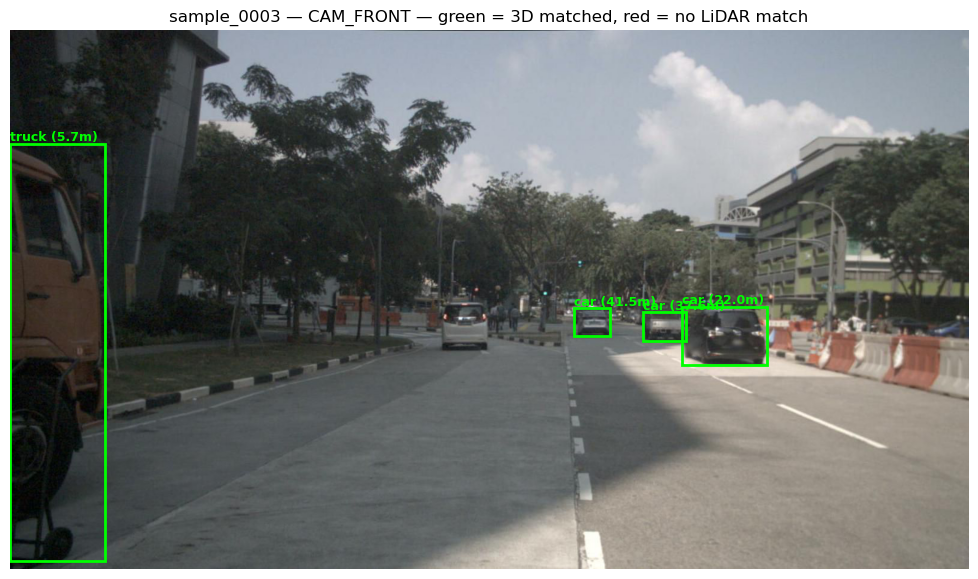

📄 Saved: F:\Sensor fusion Research\output\step_2\yolo_3d_check_sample_0003_CAM_FRONT.png


In [5]:
# ─────────────────────────────────────────────────────────────────
# CELL 5 — Draw YOLO boxes + estimated depth on the actual image
# ─────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

sample_id = "sample_0003"    # ← change to inspect any sample
cam_name = "CAM_FRONT"

with open(YOLO_OUT_DIR / sample_id / f"{cam_name}.json") as f:
    dets = json.load(f)

img_path = DATA_ROOT / cam_meta_data[sample_id][cam_name]["filename"]
img = Image.open(img_path)

fig, ax = plt.subplots(figsize=(13, 7))
ax.imshow(img)

for det in dets:
    color = 'lime' if det["has_3d_position"] else 'red'
    rect = patches.Rectangle(
        (det["xmin"], det["ymin"]),
        det["xmax"] - det["xmin"], det["ymax"] - det["ymin"],
        linewidth=2, edgecolor=color, facecolor='none'
    )
    ax.add_patch(rect)
    label = det["class_name"]
    if det["has_3d_position"]:
        label += f" ({det['estimated_depth_m']:.1f}m)"
    ax.text(det["xmin"], det["ymin"] - 5, label, color=color, fontsize=9, weight='bold')

ax.set_title(f"{sample_id} — {cam_name} — green = 3D matched, red = no LiDAR match")
ax.axis('off')

save_path = STEP2_DIR / f"yolo_3d_check_{sample_id}_{cam_name}.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📄 Saved: {save_path}")